In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_color_thermometers_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, visualize_per_channel_level_heatmaps, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 20:04:01,439 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 20:04:01,445 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 20:04:01,458 - matplotlib - DEBUG - interactive is False
2026-05-10 20:04:01,459 - matplotlib - DEBUG - platform is linux
2026-05-10 20:04:01,513 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 20:04:01,515 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
resolution=8

In [3]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.COLOR_ENCODING
CURRENT_DATASET = config.PNEUMONIAMNIST
CURRENT_RESOLUTION = resolution 
specialist_name = ["Color Encoding"]

In [4]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [5]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_color_thermometers_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test, resolution)

In [6]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [ ]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=1)

[I 2026-03-16 20:13:17,808] A new study created in memory with name: no-name-fcf5afae-a6e9-4388-8097-54d32bef6fc9


[I 2026-03-16 21:16:44,606] Trial 0 finished with value: 0.9590461378952825 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.9590461378952825.


[I 2026-03-16 22:18:20,411] Trial 1 finished with value: 0.9633264462809917 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 1 with value: 0.9633264462809917.


[I 2026-03-16 23:53:35,339] Trial 2 finished with value: 0.9778692743180648 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.9778692743180648.


[I 2026-03-17 01:14:38,355] Trial 3 finished with value: 0.9835221421215242 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 3 with value: 0.9835221421215242.


...

[I 2026-03-19 00:40:58,325] Trial 46 finished with value: 0.9731543624161074 and parameters: {'s': 6.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 23 with value: 0.986639260020555.


[I 2026-03-19 01:11:09,203] Trial 47 finished with value: 0.9742268041237113 and parameters: {'s': 9.0, 'T': 4500, 'patch_size': 9, 'max_included_literals': 512}. Best is trial 23 with value: 0.986639260020555.


[I 2026-03-19 01:28:45,138] Trial 48 finished with value: 0.9580528223718281 and parameters: {'s': 13.0, 'T': 10000, 'patch_size': 5, 'max_included_literals': 128}. Best is trial 23 with value: 0.986639260020555.


[I 2026-03-19 01:54:00,227] Trial 49 finished with value: 0.9596482152095189 and parameters: {'s': 12.0, 'T': 3000, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 23 with value: 0.986639260020555.


Best fbeta: 0.986639260020555
Best hyperparameters: {'s': 11.0, 'T': 4500, 'patch_size': 9, 'max_included_literals': 128}


In [8]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/color_thermometers.json")

Best F1 score macro accuracy: 0.986639260020555
Best hyperparameters: {'s': 11.0, 'T': 4500, 'patch_size': 9, 'max_included_literals': 128}
Best Optuna results saved to hyperparameters/color_thermometers.json


In [7]:
best_value, best_params = load_optuna_best_results("hyperparameters/color_thermometers.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [10]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="PneumoniaMNIST_Color_Thermometers",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 90.06% (370.29s)


#2 Accuracy: 89.90% (338.78s)


#3 Accuracy: 90.06% (327.88s)


#4 Accuracy: 91.35% (320.51s)


...

#96 Accuracy: 90.22% (281.47s)


#97 Accuracy: 89.90% (280.64s)


#98 Accuracy: 90.87% (280.16s)


#99 Accuracy: 90.22% (279.99s)


#100 Accuracy: 91.19% (279.53s)


In [8]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "PneumoniaMNIST_Color_Thermometers_Specialist.pkl")

In [8]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

NameError: name 'model_path' is not defined

In [9]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

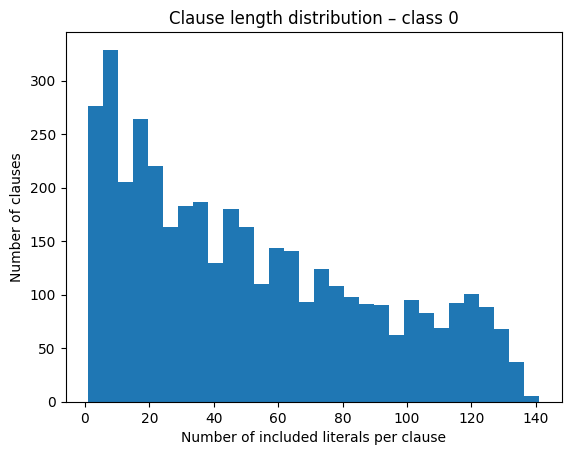

Class 0: median=44.0, mean=51.4, std=37.9


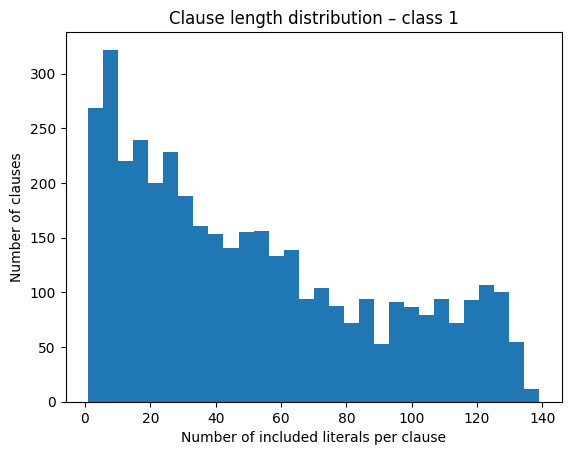

Class 1: median=43.0, mean=51.5, std=38.4


In [15]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 91.19%
2026-05-10 20:04:27,371 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x765d49a0d040>


Saved to saved_confusion_matrices/pneumonia_color_encoding.svg


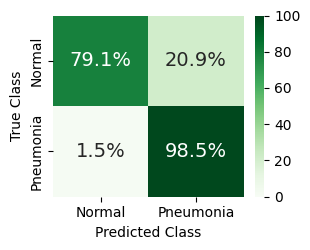

In [11]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="PneumoniaMNIST_Color_Thermometers", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap = "Greens") 

# Class 0 Local Heatmaps

In [10]:
for i in range(3): 
    print("============================================")
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 152
True class: 0
Predicted class: 0
Selected image index: 164
True class: 0
Predicted class: 0
Selected image index: 606
True class: 0
Predicted class: 0


0
2026-04-10 15:26:21,309 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:26:21,317 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 152  |  predicted class: 0
2026-04-10 15:26:21,351 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee0458a4050>
Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_lh_c0_s152_aggr.svg


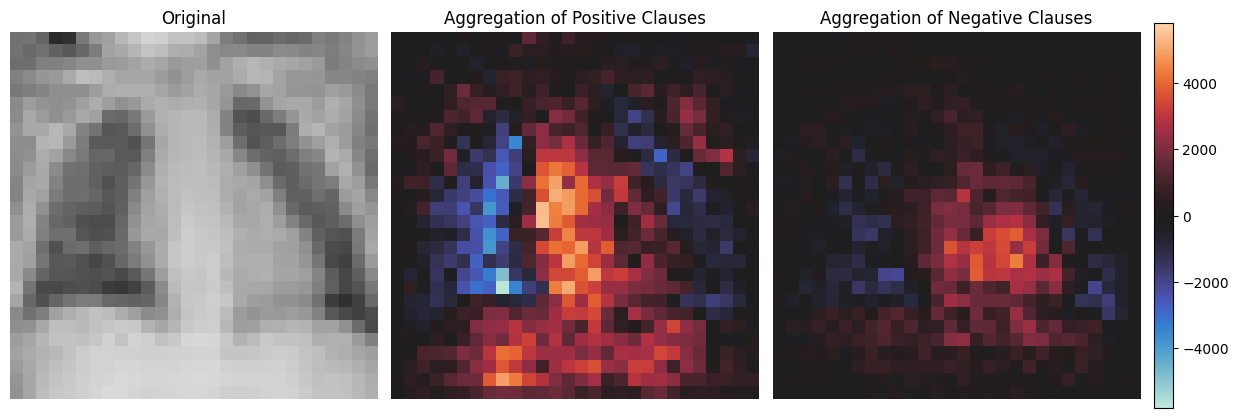

Visualizing sample 152  |  predicted class: 0
2026-04-10 15:26:29,176 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f92b650>
2026-04-10 15:26:29,336 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee045849ee0>
2026-04-10 15:26:29,365 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee0458d16d0>
2026-04-10 15:26:29,393 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03fa1eed0>
2026-04-10 15:26:29,423 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee0316aa5d0>
2026-04-10 15:26:29,450 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f54f3b0>
2026-04-10 15:26:29,479 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee0316551f0>
2026-04-10 15:26:29,508 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

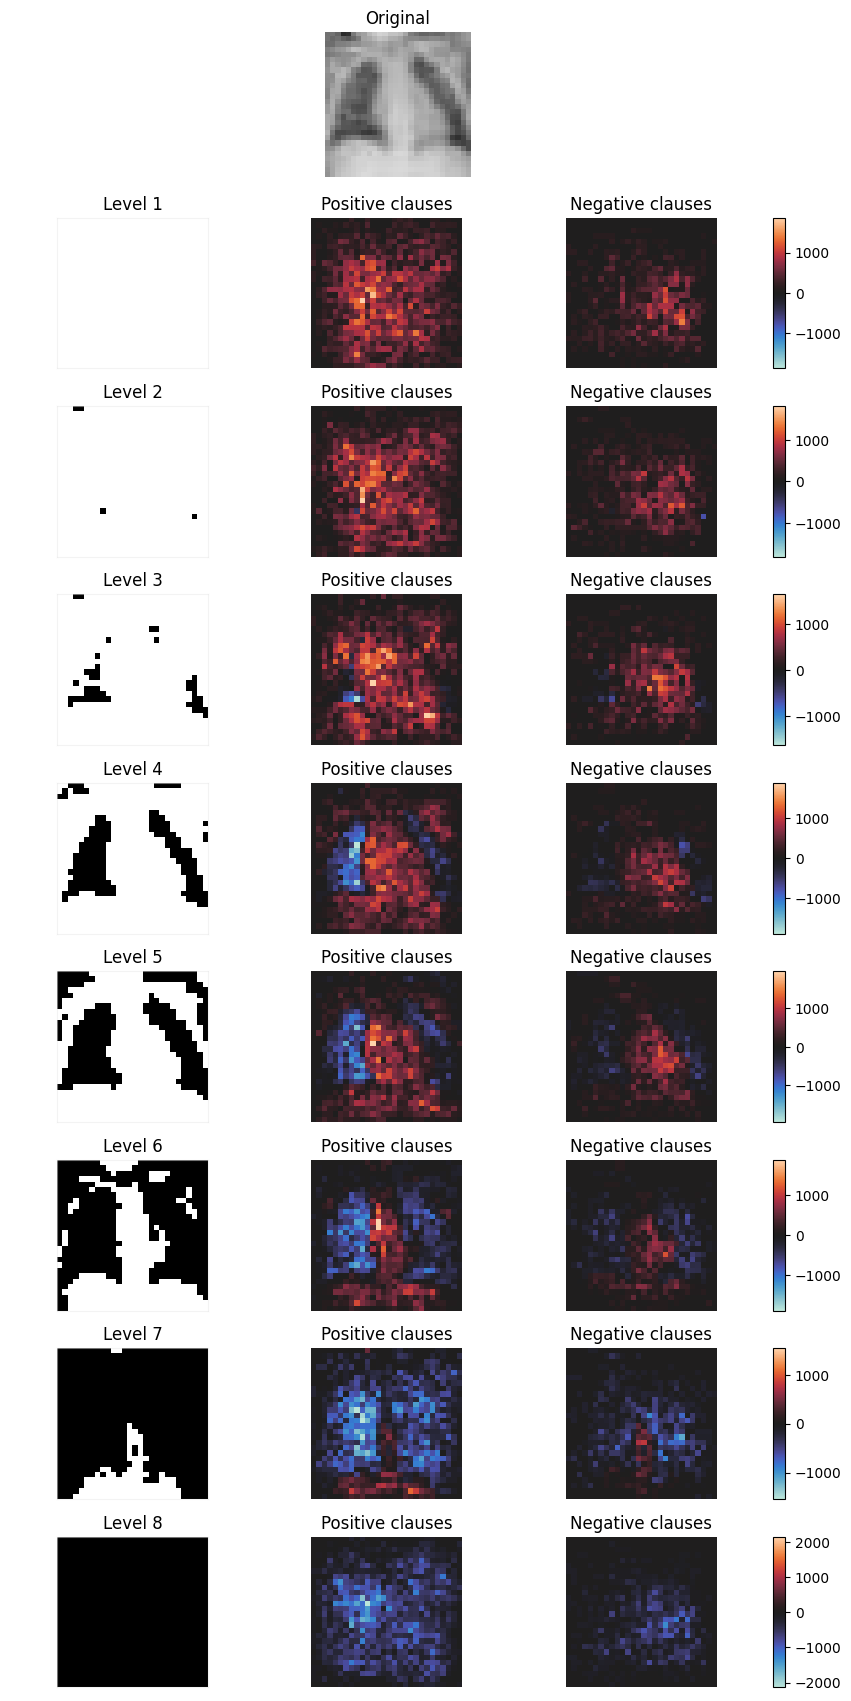

In [10]:
image_index =  152
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0
Visualizing sample 164  |  predicted class: 0
2026-04-10 15:26:46,357 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f28d7c0>
Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_lh_c0_s164_aggr.svg


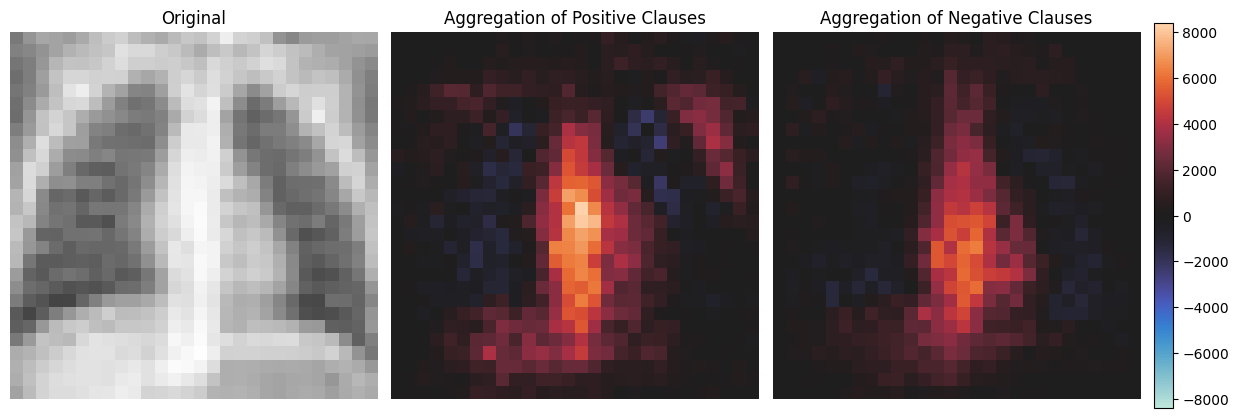

Visualizing sample 164  |  predicted class: 0
2026-04-10 15:27:03,052 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d9c69c0>
2026-04-10 15:27:03,274 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d76cd10>
2026-04-10 15:27:03,310 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d9303b0>
2026-04-10 15:27:03,352 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d71dd60>
2026-04-10 15:27:03,386 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f3686e0>
2026-04-10 15:27:03,420 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f8d5eb0>
2026-04-10 15:27:03,448 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f9d7740>
2026-04-10 15:27:03,475 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

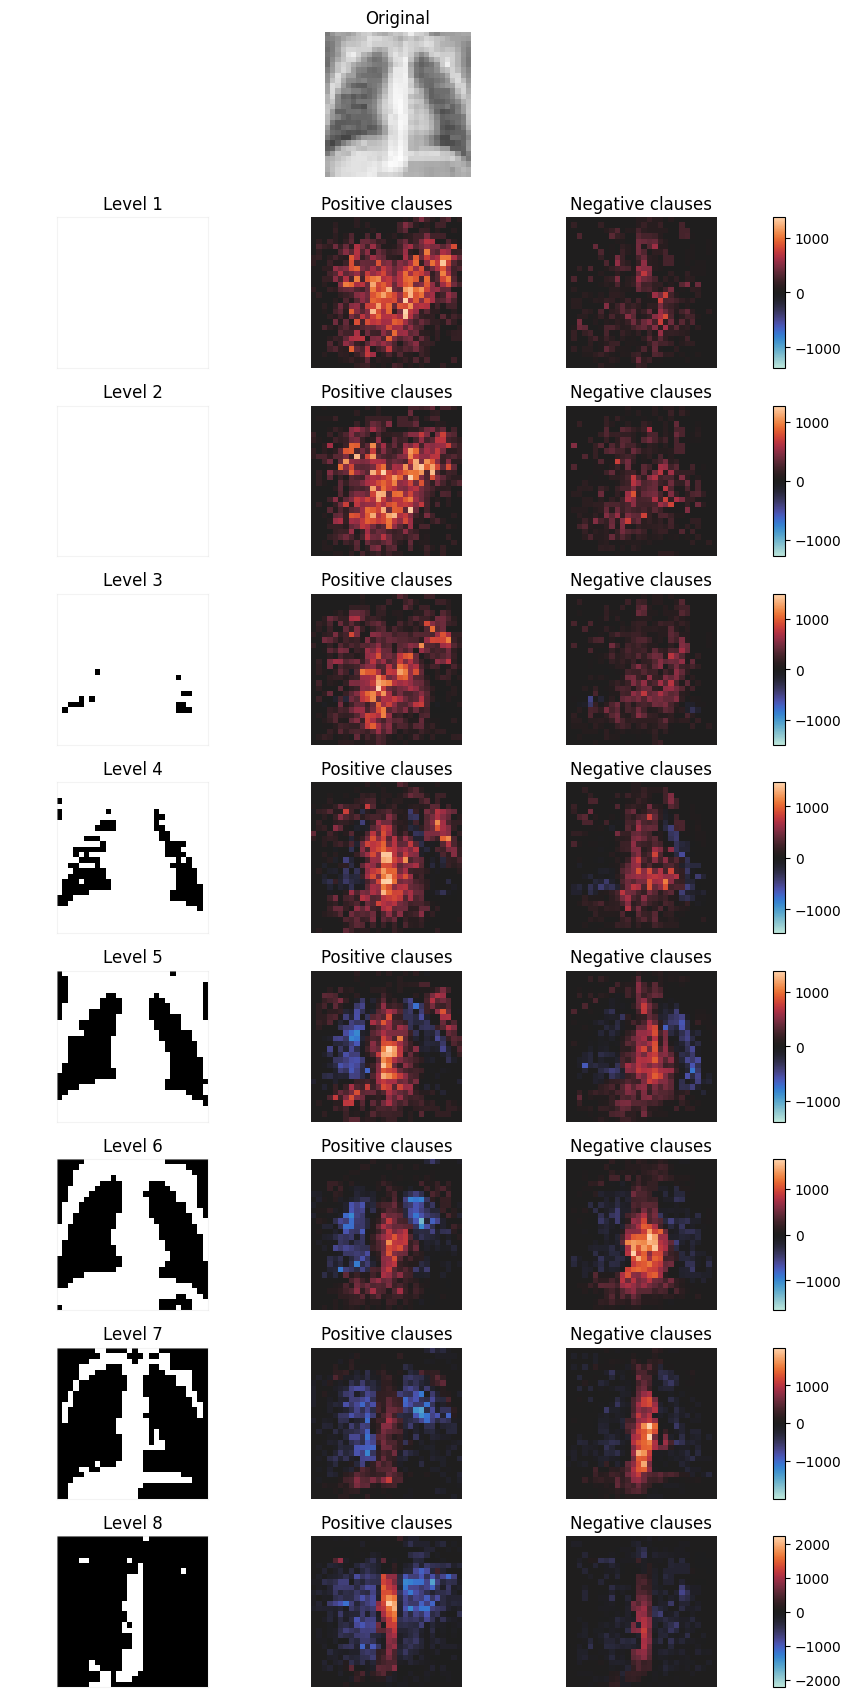

In [11]:
image_index =  164
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

0
Visualizing sample 606  |  predicted class: 0
2026-04-10 15:27:14,005 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d90b2f0>
Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_lh_c0_s606_aggr.svg


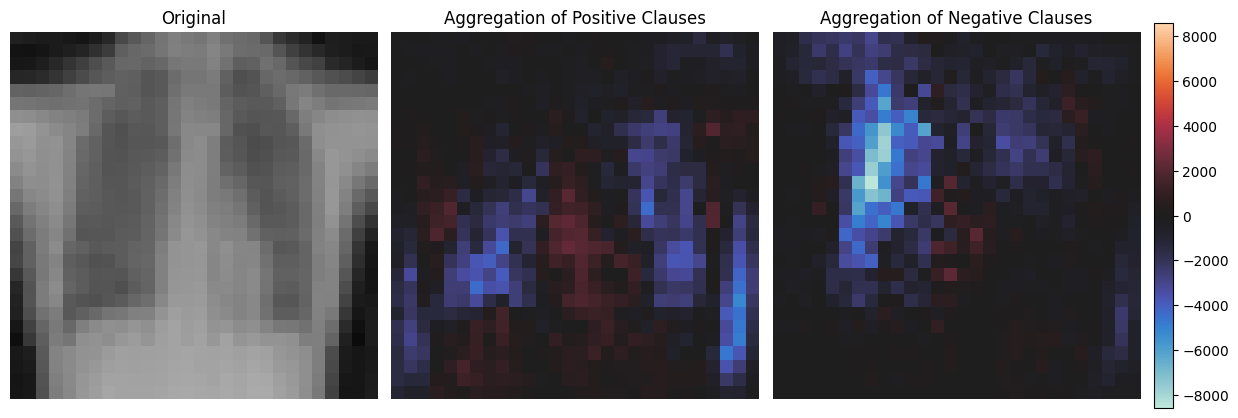

Visualizing sample 606  |  predicted class: 0
2026-04-10 15:27:23,429 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03fa1ddc0>
2026-04-10 15:27:23,456 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03fa6cef0>
2026-04-10 15:27:23,616 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f4d1d00>
2026-04-10 15:27:23,643 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f9287d0>
2026-04-10 15:27:23,671 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d7986b0>
2026-04-10 15:27:23,700 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f425130>
2026-04-10 15:27:23,729 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f886a50>
2026-04-10 15:27:23,756 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

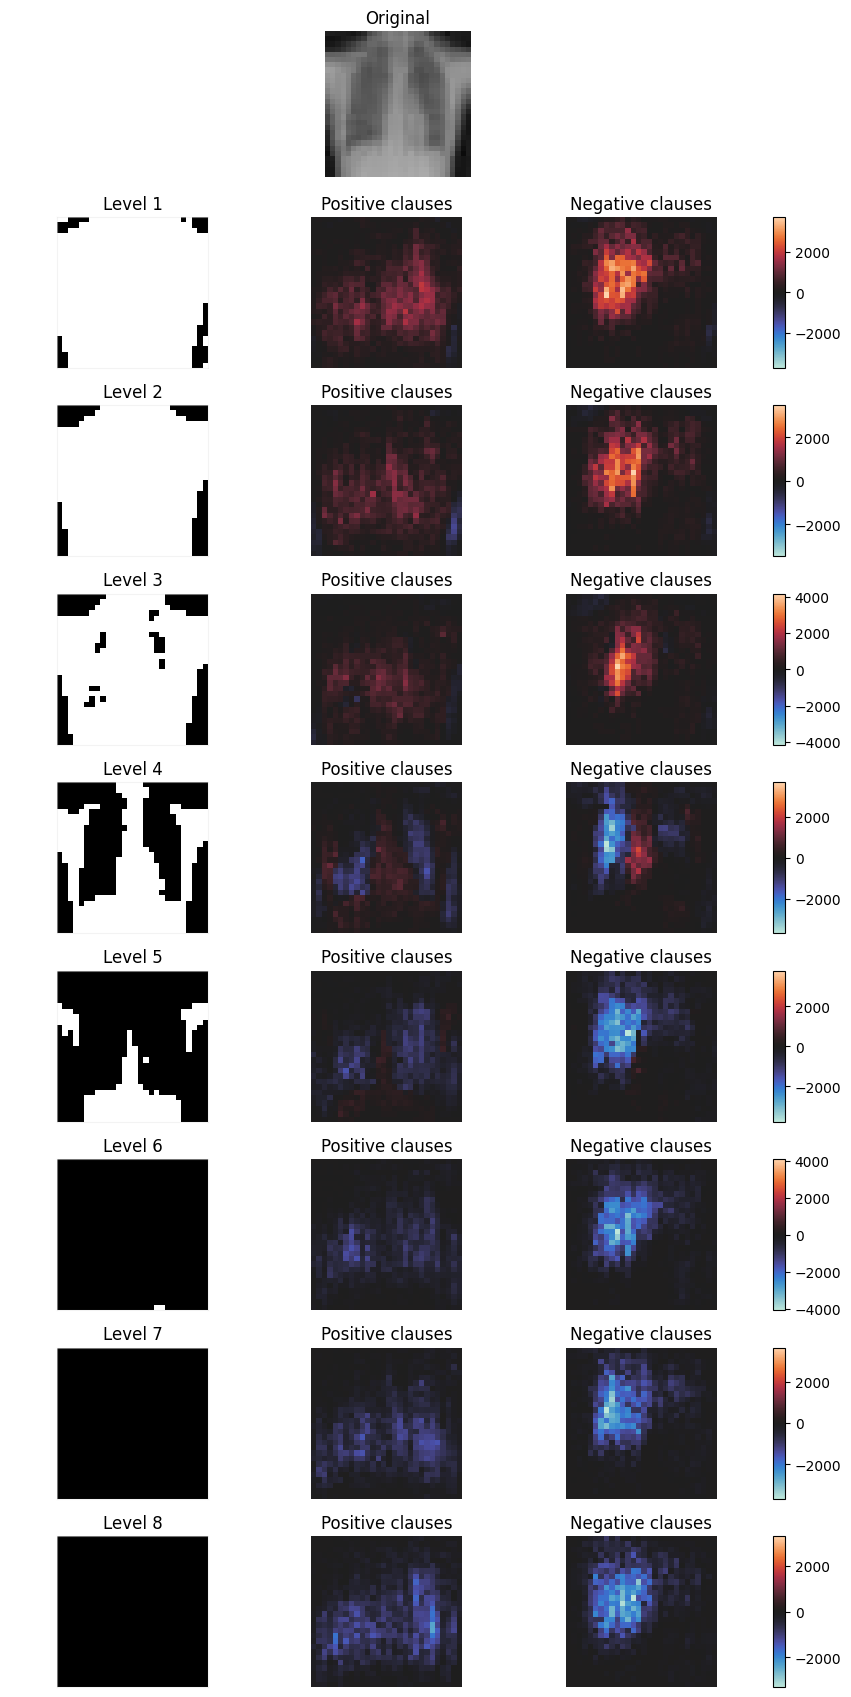

In [12]:
image_index =  606
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

# Class 1 Local Examples 

In [15]:
for i in range(3): 
    print("============================================")
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 512
True class: 1
Predicted class: 1
Selected image index: 610
True class: 1
Predicted class: 1
Selected image index: 474
True class: 1
Predicted class: 1


1
Visualizing sample 512  |  predicted class: 1
2026-04-10 15:27:39,107 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f8d63f0>
Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_lh_c1_s512_aggr.svg


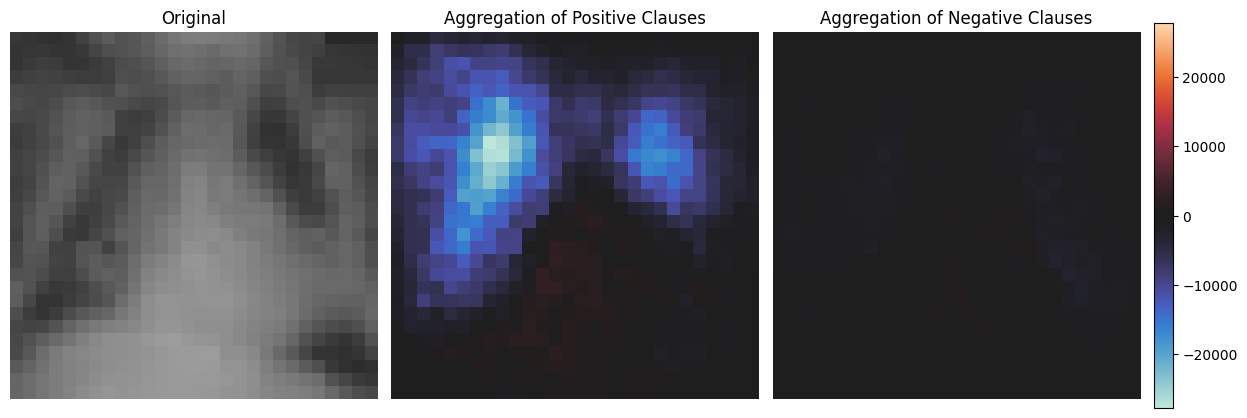

Visualizing sample 512  |  predicted class: 1
2026-04-10 15:27:52,670 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f9d4410>
2026-04-10 15:27:52,700 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f23e420>
2026-04-10 15:27:52,730 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f3d2b40>
2026-04-10 15:27:52,908 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f23ddf0>
2026-04-10 15:27:52,937 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f479670>
2026-04-10 15:27:52,963 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d65d040>
2026-04-10 15:27:52,990 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03fa42b10>
2026-04-10 15:27:53,018 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

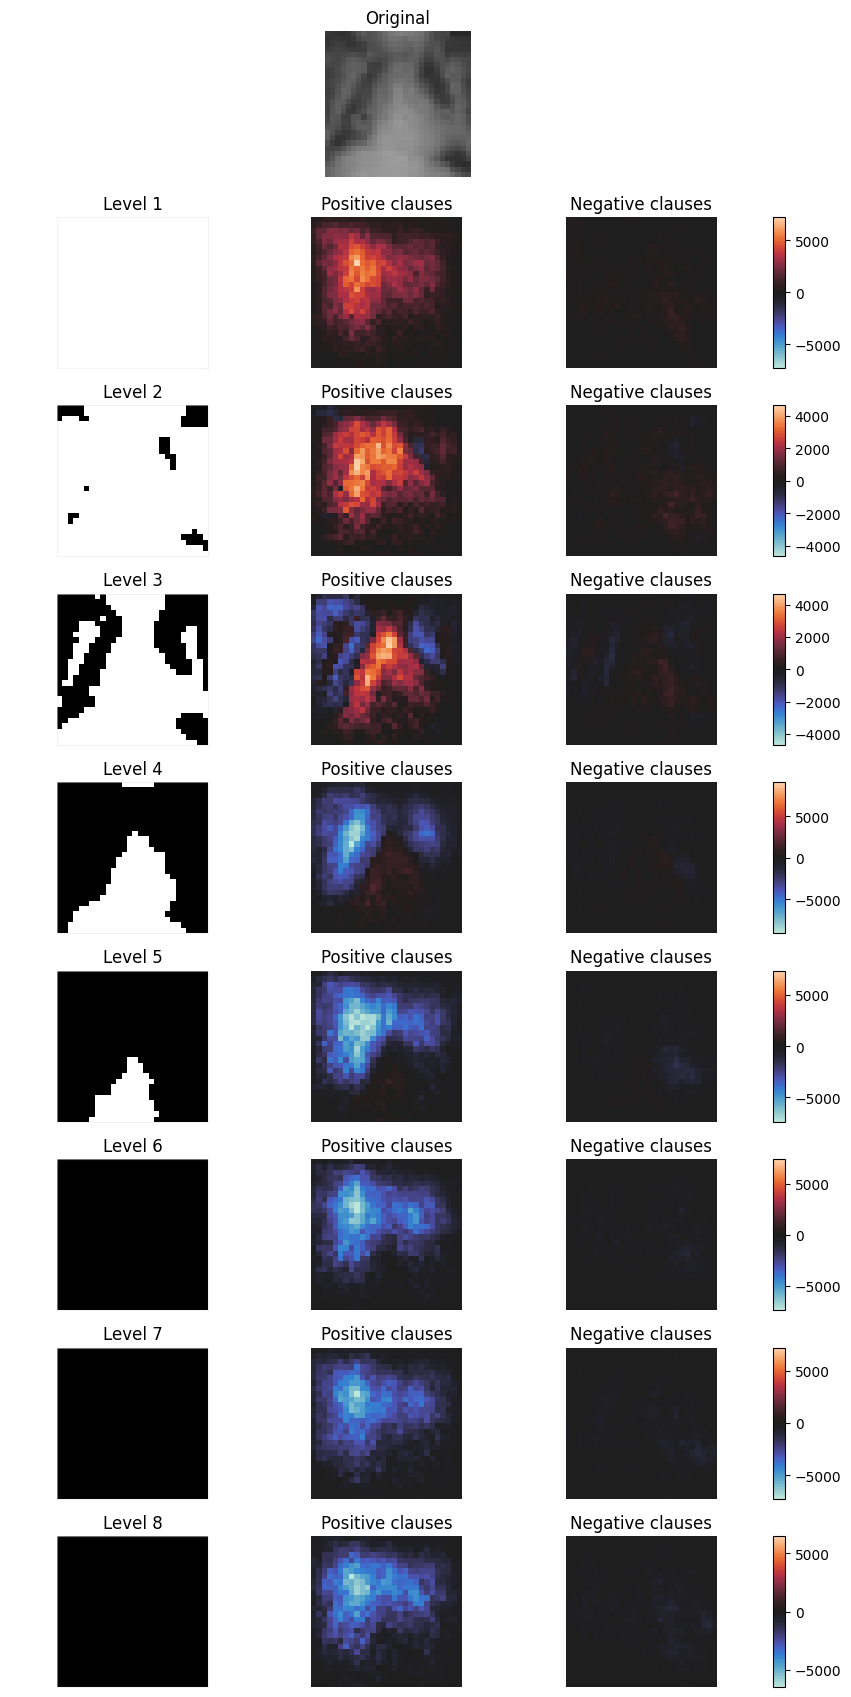

In [13]:
image_index =  512
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

1
Visualizing sample 610  |  predicted class: 1
2026-04-10 15:28:02,047 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f2169f0>
Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_lh_c1_s610_aggr.svg


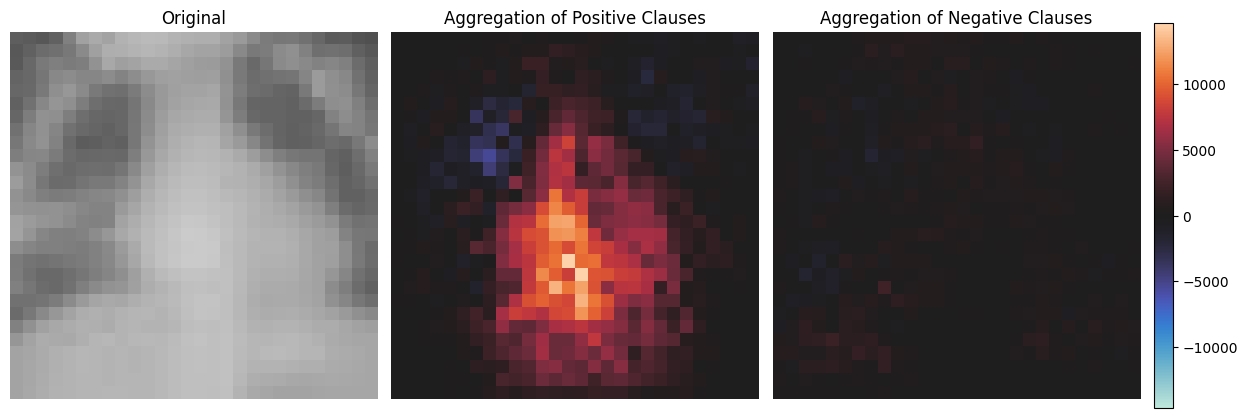

Visualizing sample 610  |  predicted class: 1
2026-04-10 15:28:10,062 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f327950>
2026-04-10 15:28:10,090 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee031707ef0>
2026-04-10 15:28:10,118 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f8fd6a0>
2026-04-10 15:28:10,146 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03fa6e780>
2026-04-10 15:28:10,316 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f9b1b50>
2026-04-10 15:28:10,344 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d50c4d0>
2026-04-10 15:28:10,372 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f29b8c0>
2026-04-10 15:28:10,400 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

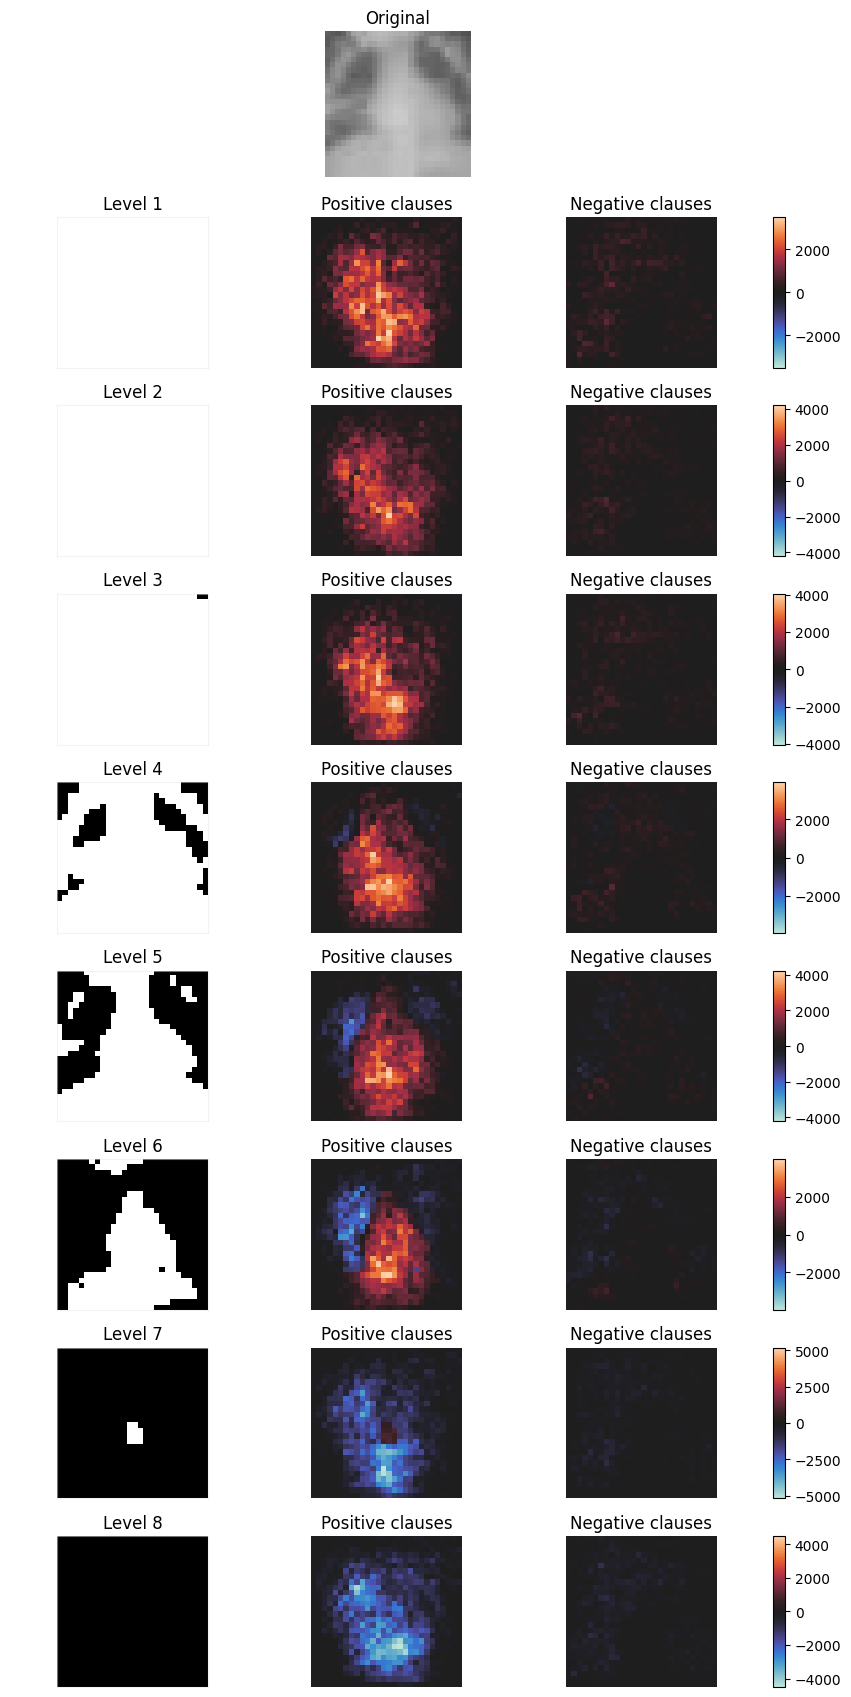

In [14]:
image_index =  610
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

1


Visualizing sample 474  |  predicted class: 1
2026-04-10 15:28:20,566 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee0458d1550>
Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_lh_c1_s474_aggr.svg


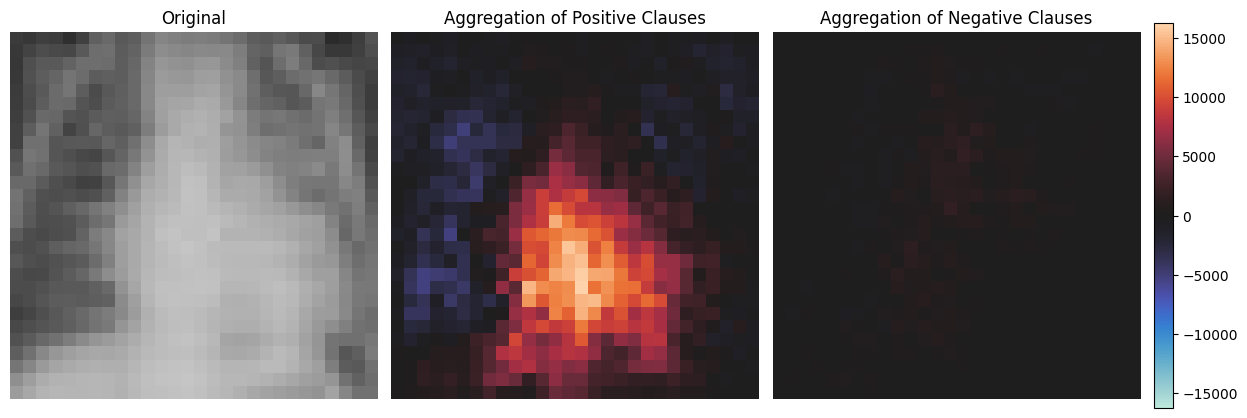

Visualizing sample 474  |  predicted class: 1
2026-04-10 15:28:29,476 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03f97eb10>
2026-04-10 15:28:29,504 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f527560>
2026-04-10 15:28:29,531 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee03171f5c0>
2026-04-10 15:28:29,557 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02f214d40>
2026-04-10 15:28:29,584 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d9a7fe0>
2026-04-10 15:28:29,744 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d442c90>
2026-04-10 15:28:29,772 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee02d50d8b0>
2026-04-10 15:28:29,799 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator obje

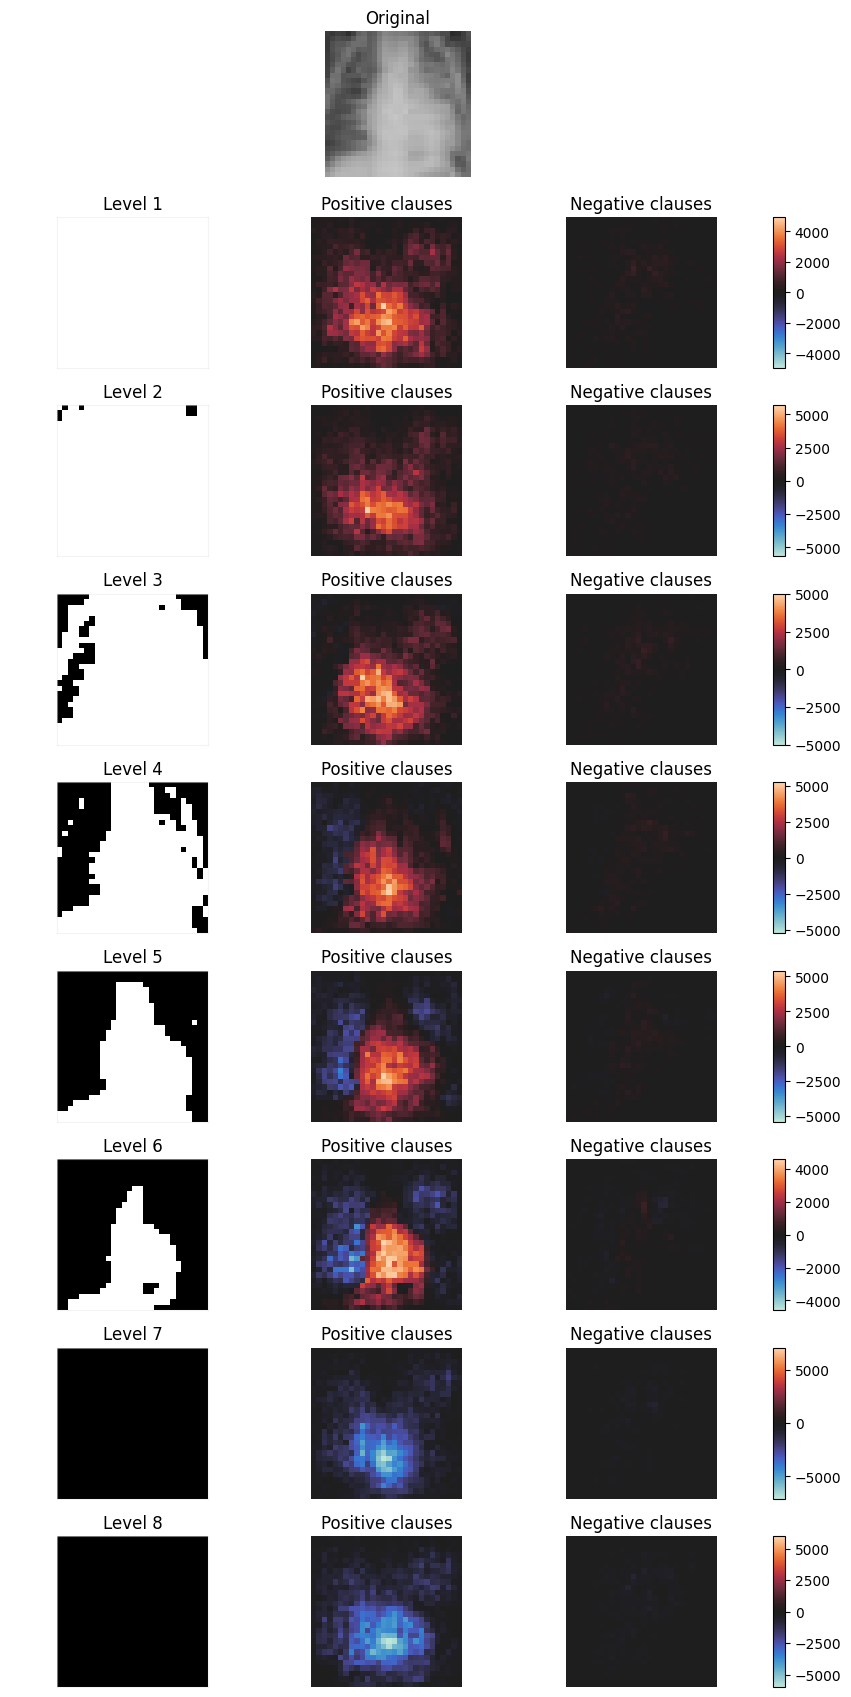

In [15]:
image_index =  474
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)
save_path_per_resolution=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST), CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.RES_HEATMAP, image_index)
visualize_per_channel_level_heatmaps(X_test, X_test_org, tm, image_index, 
    resolution=CURRENT_RESOLUTION, n_channels=config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=None, save_path=save_path_per_resolution)

# Global Heatmap 0

Averaging over 185 correctly predicted samples of class 0
  processed 100/185
2026-04-09 20:56:37,816 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b52f1ad4170>


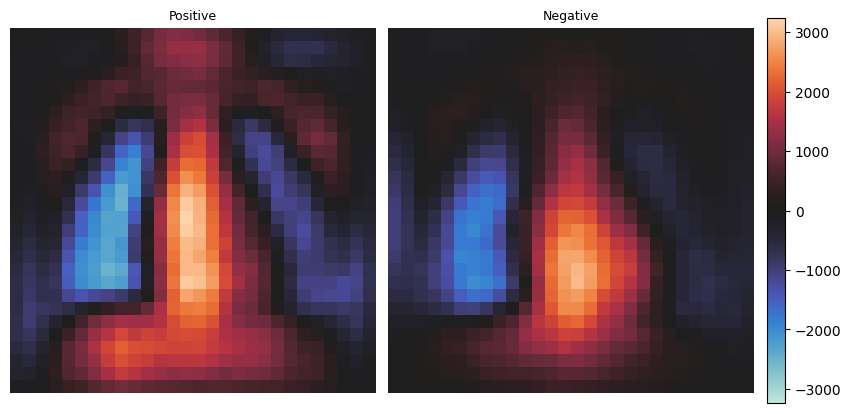

In [16]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 0

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:14:46,104 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:14:46,107 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:14:46,135 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eeb7ce46fc0>


Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_gh_c0.svg


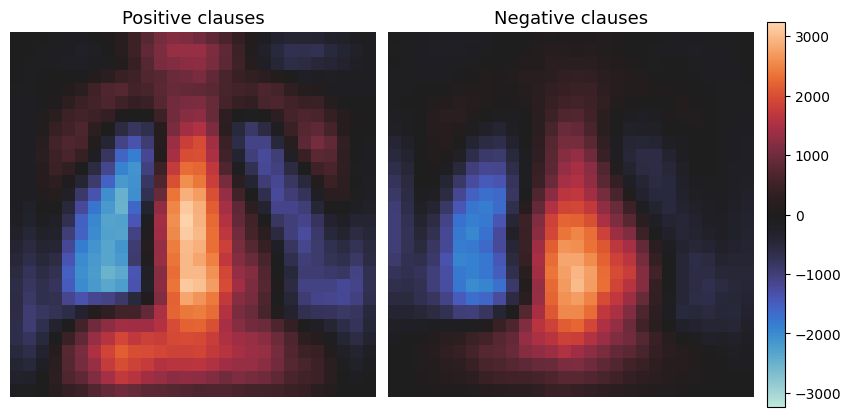

pos shape: (28, 28), min: -2520.99, max: 3235.84
neg shape: (28, 28), min: -2014.07, max: 2999.83
saved_heatmaps/color_encoding/pneumonia_color_encoding_gh_c0.svg


In [7]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1

Averaging over 384 correctly predicted samples of class 1
  processed 100/384
  processed 200/384
  processed 300/384
2026-04-09 21:52:27,360 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b52ef79cb90>


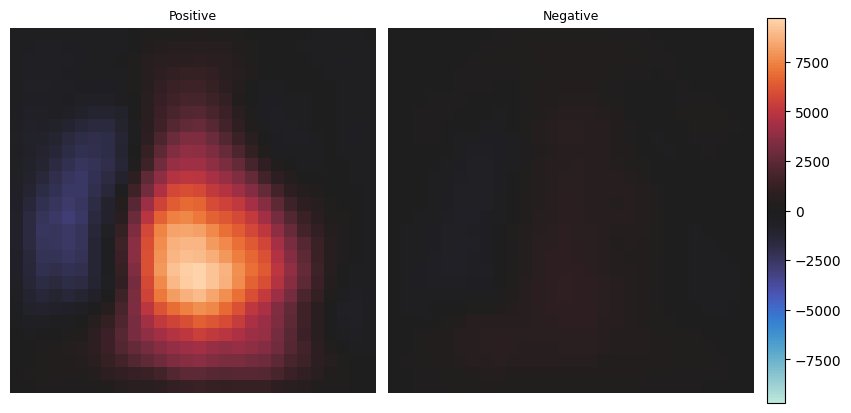

In [17]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 1

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:14:50,355 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7eeb77d0acf0>


Saved to saved_heatmaps/color_encoding/pneumonia_color_encoding_gh_c1.svg


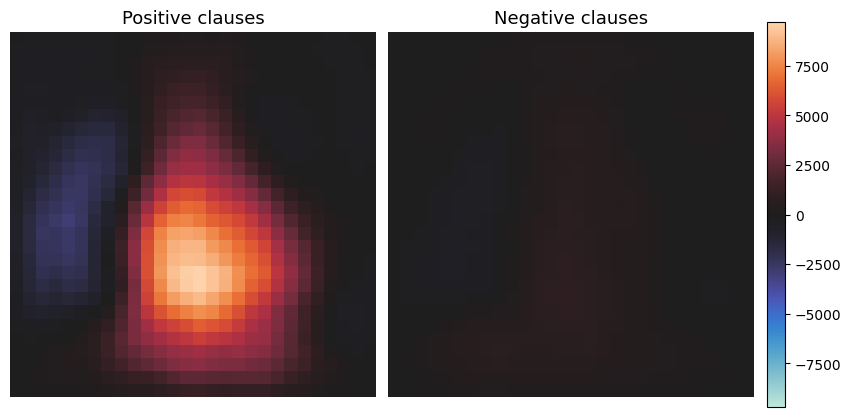

pos shape: (28, 28), min: -2911.04, max: 9703.54
neg shape: (28, 28), min: -634.83, max: 954.77
saved_heatmaps/color_encoding/pneumonia_color_encoding_gh_c1.svg


In [8]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)